# Fine-tuned ModernBERT — Bitext intent classification (EDA)

This notebook explores **test-set performance** of the fine-tuned multiclass model on the bitext dataset.

**Sources**
- Metrics & misclassifications: `training/data/bitext/test_metrics.json`
- Confusion matrix: `training/data/bitext/label_confusion_matrix.csv`

**Run cells top-to-bottom.** The notebook resolves paths from the repo root or from `notebooks/`.

**Optional packages:** `pip install wordcloud` enables the misclassification word cloud. Plotly is used when available; otherwise matplotlib fallbacks run.

In [1]:
# --- Setup: imports & paths ---
from __future__ import annotations

import json
import re
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import cohen_kappa_score

try:
    import seaborn as sns

    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False
    sns = None  # type: ignore[assignment]
    print("seaborn not installed; heatmaps use matplotlib. Install: pip install seaborn")

warnings.filterwarnings("ignore", category=FutureWarning)


def plot_heatmap(
    data,
    ax=None,
    xticklabels=None,
    yticklabels=None,
    cmap="viridis",
    square=False,
    cbar_kws=None,
    **kwargs,
):
    """Seaborn heatmap when available; otherwise matplotlib ``imshow``."""
    cbar_kws = cbar_kws or {}
    cbar_label = cbar_kws.get("label")
    if HAS_SEABORN:
        return sns.heatmap(
            data,
            ax=ax,
            xticklabels=xticklabels,
            yticklabels=yticklabels,
            cmap=cmap,
            square=square,
            cbar_kws=cbar_kws,
            **kwargs,
        )
    arr = np.asarray(data, dtype=float)
    if ax is None:
        ax = plt.gca()
    aspect = "equal" if square else "auto"
    im = ax.imshow(arr, cmap=cmap, aspect=aspect, interpolation="nearest")
    cb = plt.colorbar(im, ax=ax)
    if cbar_label:
        cb.set_label(cbar_label)
    ny, nx = arr.shape
    if xticklabels is not None:
        ax.set_xticks(np.arange(nx))
        ax.set_xticklabels(xticklabels, rotation=90, fontsize=7)
    if yticklabels is not None:
        ax.set_yticks(np.arange(ny))
        ax.set_yticklabels(yticklabels, fontsize=7)
    return im



# Optional: interactive plots
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    HAS_PLOTLY = True
except ImportError:
    HAS_PLOTLY = False
    print("plotly not installed; radar/bubble charts will use matplotlib fallbacks.")

try:
    from wordcloud import WordCloud

    HAS_WORDCLOUD = True
except ImportError:
    HAS_WORDCLOUD = False
    print("wordcloud not installed; word cloud cell will be skipped.")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks" or not (PROJECT_ROOT / "training").exists():
    PROJECT_ROOT = (PROJECT_ROOT / "..").resolve()

DATA_DIR = PROJECT_ROOT / "training" / "data" / "bitext"
METRICS_PATH = DATA_DIR / "test_metrics.json"
CM_PATH = DATA_DIR / "label_confusion_matrix.csv"

if HAS_SEABORN:
    sns.set_theme(style="whitegrid", context="notebook")
else:
    plt.rcParams["axes.grid"] = True
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

with open(METRICS_PATH, encoding="utf-8") as f:
    metrics_blob = json.load(f)

cm_df = pd.read_csv(CM_PATH, index_col=0)
# Ensure numeric
cm_df = cm_df.apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)

per_label = pd.DataFrame.from_dict(metrics_blob["per_label_metrics"], orient="index")
per_label = per_label.sort_values("label_id")
per_label["support"] = per_label["tp"] + per_label["fn"]

mis_df = pd.DataFrame(metrics_blob.get("misclassified_samples", []))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Checkpoint:", metrics_blob.get("checkpoint"))
print("Test samples:", metrics_blob.get("num_samples"), "| Labels:", metrics_blob.get("num_labels"))
print("Confusion matrix shape:", cm_df.shape)
print("Misclassified rows:", len(mis_df))

seaborn not installed; heatmaps use matplotlib. Install: pip install seaborn
plotly not installed; radar/bubble charts will use matplotlib fallbacks.
PROJECT_ROOT: D:\ai_ws\projects\iBud
Checkpoint: D:\ai_ws\projects\iBud\training\models\bitext\checkpoint-1296
Test samples: 4471 | Labels: 28
Confusion matrix shape: (28, 28)
Misclassified rows: 193


## 2. Overall performance dashboard

Aggregate metrics from the evaluation run (accuracy, macro/weighted F1, MCC, ROC-AUC OVR macro, PR-AUC macro).

,metric,value
0,eval_accuracy,0.956833
1,eval_precision_macro,0.953907
2,eval_recall_macro,0.950055
3,eval_f1_macro,0.951583
4,eval_precision_weighted,0.957606
5,eval_recall_weighted,0.956833
6,eval_f1_weighted,0.956958
7,eval_mcc,0.954183
8,eval_roc_auc_ovr_macro,0.999420
9,eval_pr_auc_macro,0.988039


Cohen kappa (from confusion matrix): 0.9541664681474527


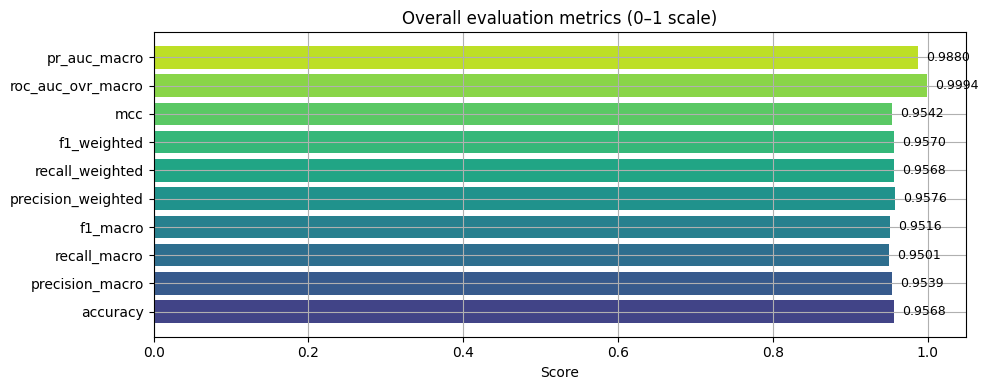

Insight: ROC-AUC (OVR macro) is very high while macro F1 reflects harder class imbalance / calibration trade-offs.


In [2]:
overall = metrics_blob.get("metrics", {})
# Select key scalar metrics for the dashboard
key_keys = [
    "eval_accuracy",
    "eval_precision_macro",
    "eval_recall_macro",
    "eval_f1_macro",
    "eval_precision_weighted",
    "eval_recall_weighted",
    "eval_f1_weighted",
    "eval_mcc",
    "eval_roc_auc_ovr_macro",
    "eval_pr_auc_macro",
    "eval_loss",
]
overview = {k: overall[k] for k in key_keys if k in overall}

ov_df = pd.Series(overview, name="value").rename_axis("metric").reset_index()
display(ov_df.style.format({"value": "{:.6f}"}))

# Cohen kappa from full confusion matrix (sanity check vs eval_mcc / accuracy)
y_true_k, y_pred_k = [], []
for ti in cm_df.index:
    for pj in cm_df.columns:
        n = int(cm_df.loc[ti, pj])
        y_true_k.extend([ti] * n)
        y_pred_k.extend([pj] * n)
print("Cohen kappa (from confusion matrix):", float(cohen_kappa_score(y_true_k, y_pred_k)))

# Bar chart: exclude loss for 0-1 scale comparison
plot_keys = [k for k in key_keys if k in overall and k != "eval_loss"]
vals = [overall[k] for k in plot_keys]
labels = [k.replace("eval_", "") for k in plot_keys]
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(plot_keys)))

fig, ax = plt.subplots(figsize=(10, max(4, len(plot_keys) * 0.35)))
bars = ax.barh(labels, vals, color=colors)
ax.set_xlim(0, 1.05)
ax.set_xlabel("Score")
ax.set_title("Overall evaluation metrics (0–1 scale)")
for b, v in zip(bars, vals):
    ax.text(v + 0.01, b.get_y() + b.get_height() / 2, f"{v:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print(
    "Insight: ROC-AUC (OVR macro) is very high while macro F1 reflects harder class imbalance / calibration trade-offs."
)

## 3. Class distribution (support)

Support per class = **TP + FN** (true positives for that one-vs-rest view). Highlights imbalance vs dominant classes like `no_issue`.

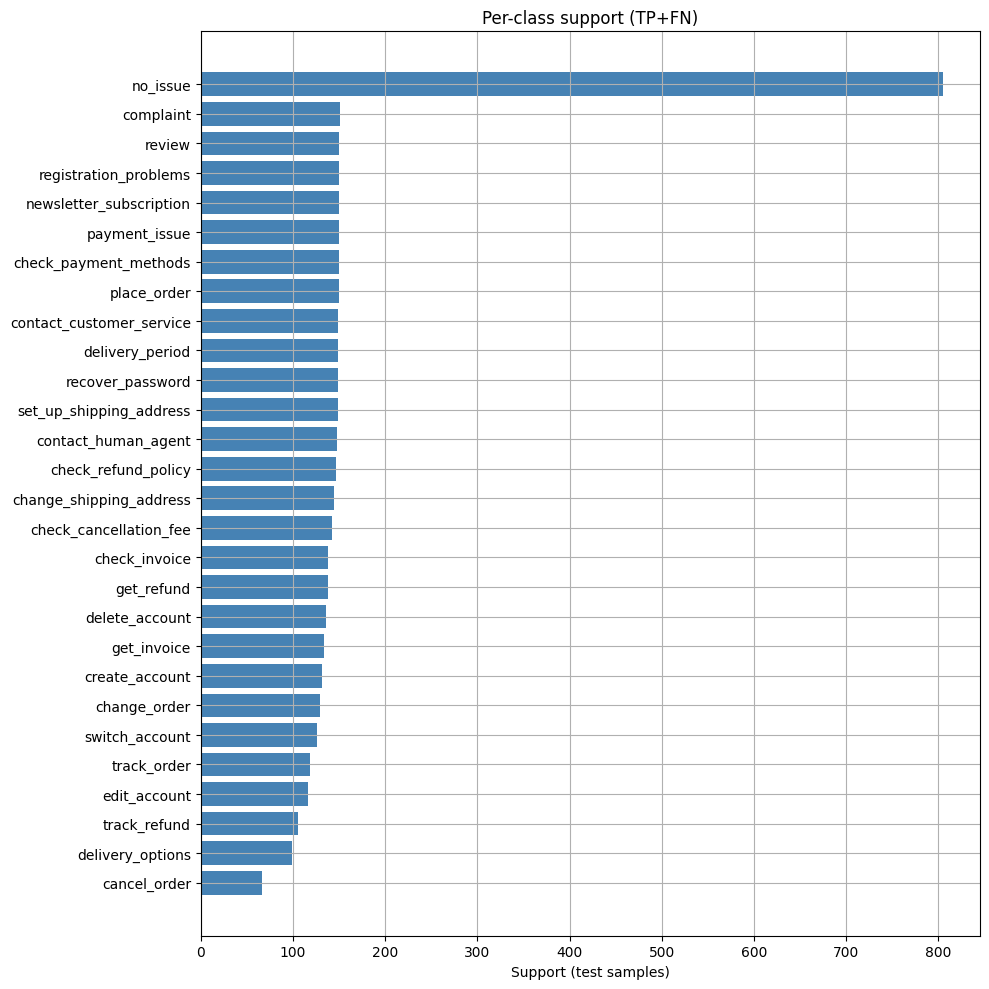

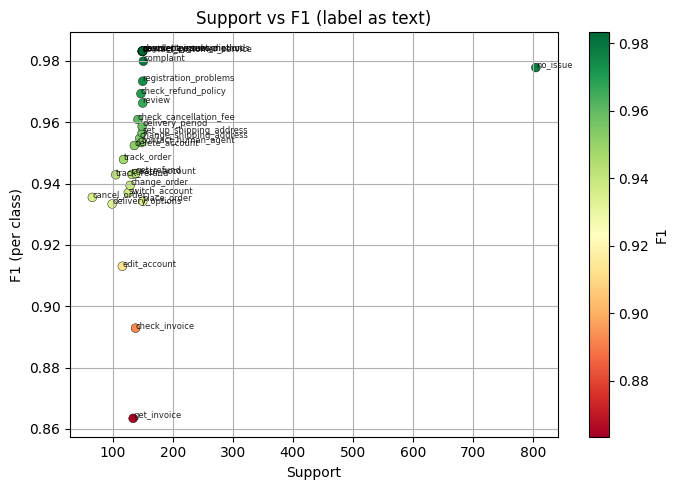

Pearson correlation(support, F1): 0.245


In [3]:
sup = per_label[["label_name", "support", "f1"]].copy().sort_values("support", ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(sup["label_name"], sup["support"], color="steelblue")
ax.set_xlabel("Support (test samples)")
ax.set_title("Per-class support (TP+FN)")
plt.tight_layout()
plt.show()

# Correlation support vs F1
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(sup["support"], sup["f1"], s=40, c=sup["f1"], cmap="RdYlGn", edgecolors="k", linewidths=0.3)
for _, r in sup.iterrows():
    ax.annotate(r["label_name"], (r["support"], r["f1"]), fontsize=6, alpha=0.85)
ax.set_xlabel("Support")
ax.set_ylabel("F1 (per class)")
ax.set_title("Support vs F1 (label as text)")
plt.colorbar(sc, ax=ax, label="F1")
plt.tight_layout()
plt.show()

rho = sup["support"].corr(sup["f1"])
print(f"Pearson correlation(support, F1): {rho:.3f}")

## 4. Per-class precision, recall, F1

Grouped bars (sorted by F1) and a **precision vs recall** view (bubble size = support).

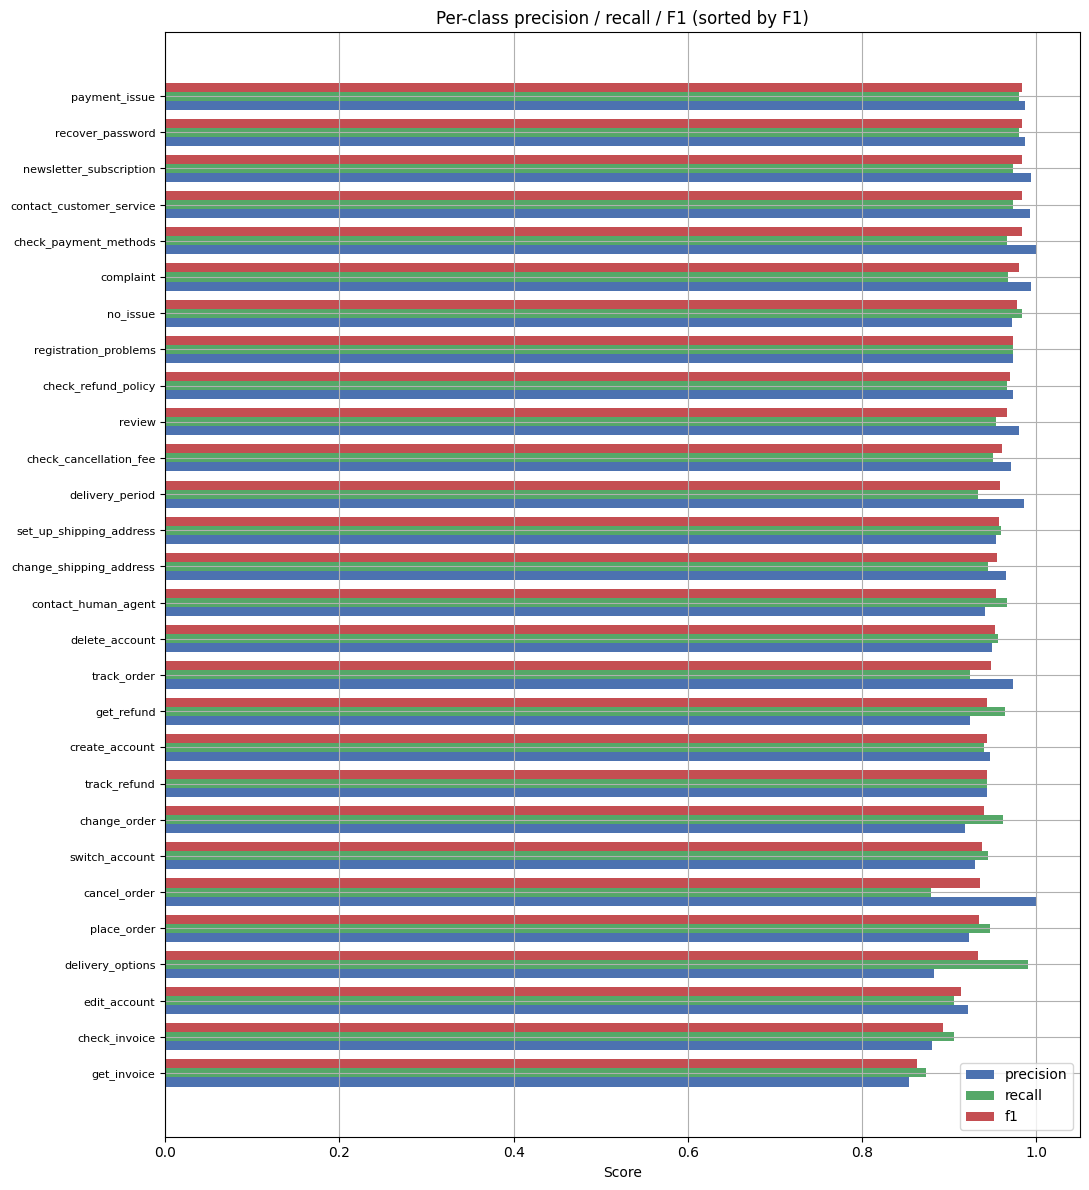

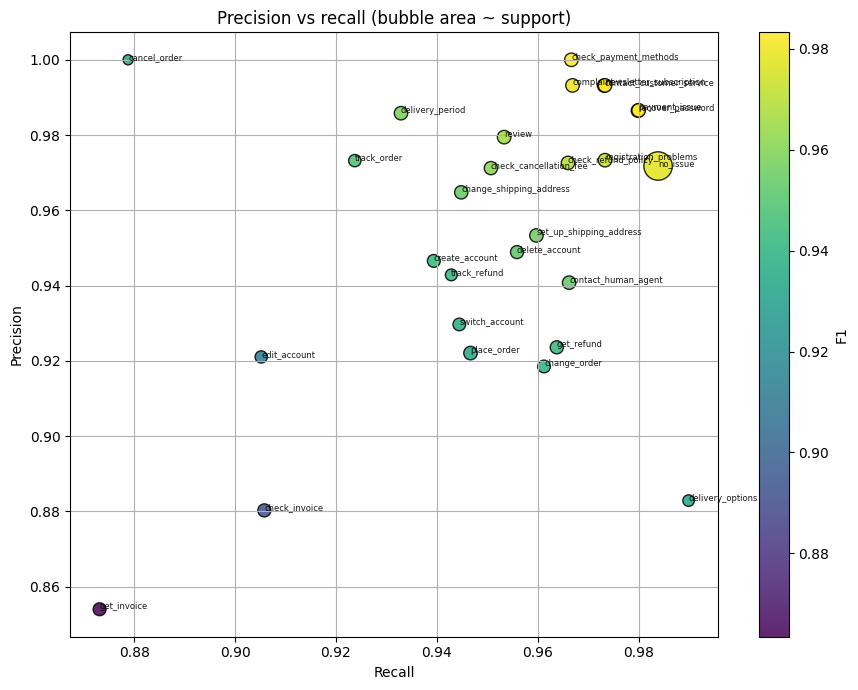

Bottom 5 by F1:
       label_name       f1
     get_invoice 0.863469
   check_invoice 0.892857
    edit_account 0.913043
delivery_options 0.933333
     place_order 0.934211

Top 5 by F1:
               label_name       f1
           payment_issue 0.983278
 newsletter_subscription 0.983165
        recover_password 0.983165
   check_payment_methods 0.983051
contact_customer_service 0.983051


In [4]:
pl = per_label.sort_values("f1", ascending=True).copy()

fig, ax = plt.subplots(figsize=(11, 12))
y = np.arange(len(pl))
h = 0.25
ax.barh(y - h, pl["precision"], height=h, label="precision", color="#4c72b0")
ax.barh(y, pl["recall"], height=h, label="recall", color="#55a868")
ax.barh(y + h, pl["f1"], height=h, label="f1", color="#c44e52")
ax.set_yticks(y)
ax.set_yticklabels(pl["label_name"], fontsize=8)
ax.set_xlabel("Score")
ax.set_title("Per-class precision / recall / F1 (sorted by F1)")
ax.legend(loc="lower right")
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()

# Bubble / scatter
if HAS_PLOTLY:
    bubble = pl.copy()
    fig = px.scatter(
        bubble,
        x="recall",
        y="precision",
        size="support",
        hover_name="label_name",
        color="f1",
        color_continuous_scale="Viridis",
        title="Precision vs recall (size = support)",
        size_max=40,
    )
    fig.update_layout(width=900, height=700)
    fig.show()
else:
    fig, ax = plt.subplots(figsize=(9, 7))
    sizes = (pl["support"] / pl["support"].max()) * 400 + 20
    sc = ax.scatter(pl["recall"], pl["precision"], s=sizes, c=pl["f1"], cmap="viridis", alpha=0.85, edgecolors="k")
    for _, r in pl.iterrows():
        ax.annotate(r["label_name"], (r["recall"], r["precision"]), fontsize=6, alpha=0.9)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision vs recall (bubble area ~ support)")
    plt.colorbar(sc, ax=ax, label="F1")
    plt.tight_layout()
    plt.show()

worst = pl.nsmallest(5, "f1")[["label_name", "f1"]]
best = pl.nlargest(5, "f1")[["label_name", "f1"]]
print("Bottom 5 by F1:\n", worst.to_string(index=False))
print("\nTop 5 by F1:\n", best.to_string(index=False))

## 5. Error analysis (TP / FP / FN)

Stacked counts and a **2-column heatmap** of FP vs FN. **Error rate** = (FP+FN) / (TP+FP+FN+TN) per class.

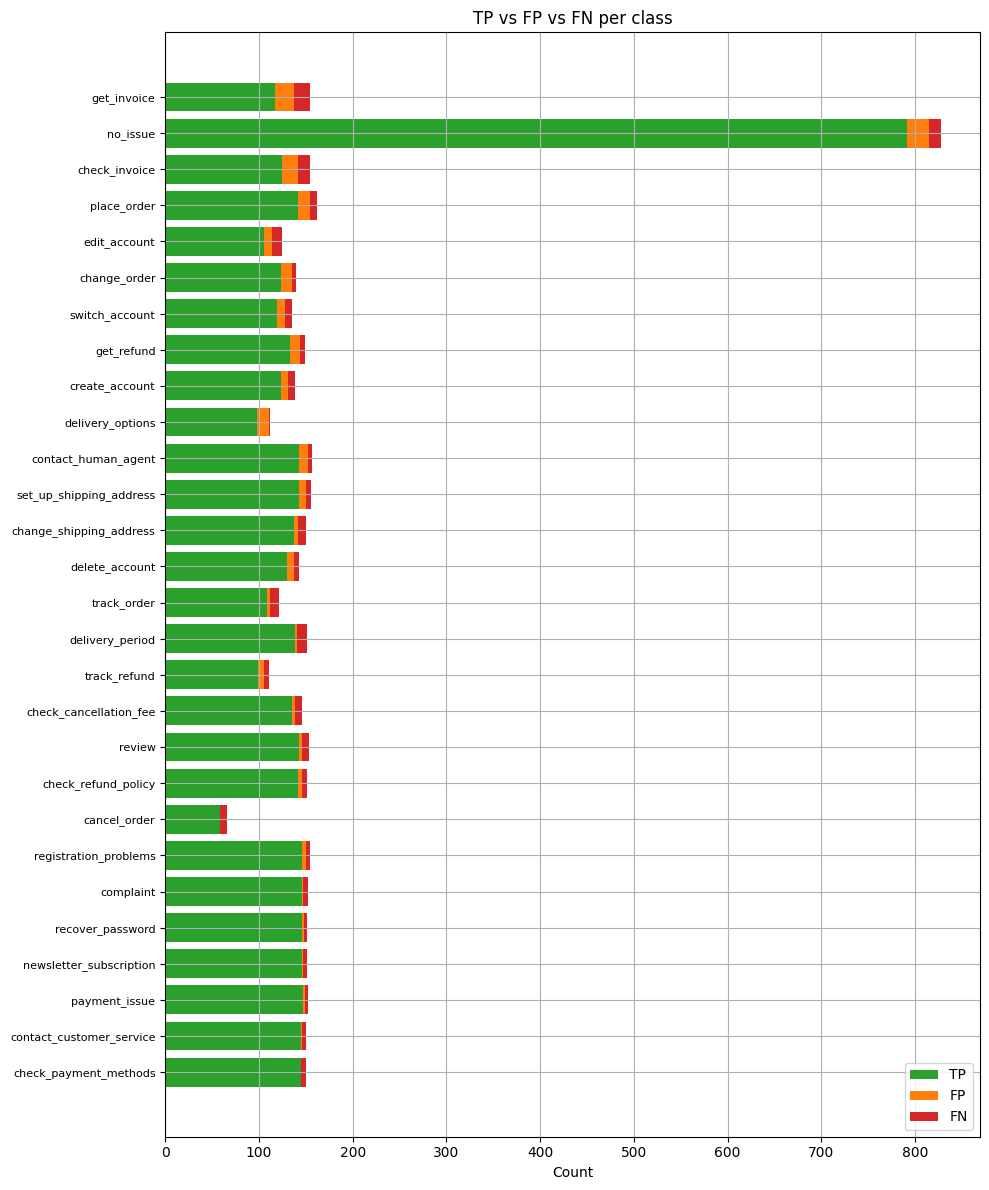

AttributeError: 'NoneType' object has no attribute 'heatmap'

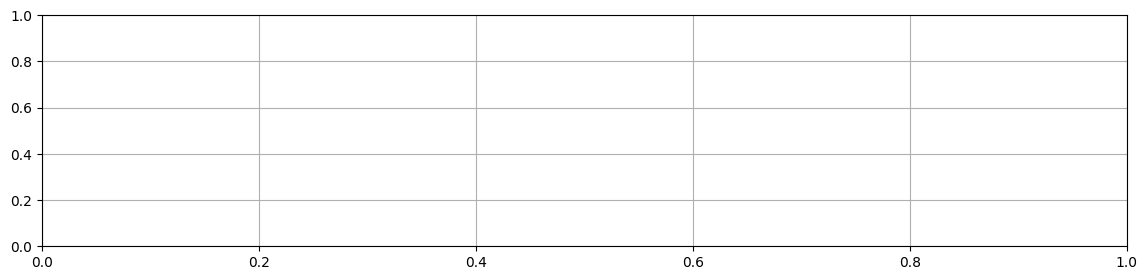

In [5]:
err = per_label.copy()
err["total"] = err["tp"] + err["fp"] + err["fn"] + err["tn"]
err["error_rate"] = (err["fp"] + err["fn"]) / err["total"].replace(0, np.nan)

e = err.sort_values("error_rate", ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
y = np.arange(len(e))
ax.barh(y, e["tp"], label="TP", color="#2ca02c")
ax.barh(y, e["fp"], left=e["tp"], label="FP", color="#ff7f0e")
ax.barh(y, e["fn"], left=e["tp"] + e["fp"], label="FN", color="#d62728")
ax.set_yticks(y)
ax.set_yticklabels(e["label_name"], fontsize=8)
ax.set_xlabel("Count")
ax.set_title("TP vs FP vs FN per class")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# FP vs FN heatmap (2 columns)
hm = e[["fp", "fn"]].T
hm.columns = e["label_name"].tolist()
fig, ax = plt.subplots(figsize=(14, 3))
plot_heatmap(
    hm,
    ax=ax,
    cmap="YlOrRd",
    annot=False,
    cbar_kws={"label": "Count"},
    xticklabels=hm.columns.tolist(),
    yticklabels=hm.index.tolist(),
)
ax.set_title("FP and FN counts per class (columns = classes)")
plt.tight_layout()
plt.show()

display(
    err[["label_name", "tp", "fp", "fn", "error_rate"]]
    .sort_values("error_rate", ascending=False)
    .style.format({"error_rate": "{:.4f}"})
)

## 6. Confusion matrix

Full matrix with **log-scaled** colour (small off-diagonal counts visible). Then **top off-diagonal pairs** and a bar chart of the top 15.

In [ ]:
labels = list(cm_df.index)
mat = cm_df.values.astype(float)
log_mat = np.log1p(mat)

fig, ax = plt.subplots(figsize=(14, 12))
plot_heatmap(
    log_mat,
    xticklabels=labels,
    yticklabels=labels,
    cmap="mako",
    square=True,
    cbar_kws={"label": "log1p(count)"},
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix (log1p colour scale)")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

# Off-diagonal pairs
pairs = []
n = len(labels)
for i in range(n):
    for j in range(n):
        if i == j:
            continue
        v = mat[i, j]
        if v > 0:
            pairs.append((labels[i], labels[j], int(v)))

pairs_df = pd.DataFrame(pairs, columns=["true_label", "predicted_label", "count"]).sort_values(
    "count", ascending=False
)

top15 = pairs_df.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
labs = [f"{r.true_label} → {r.predicted_label}" for _, r in top15.iterrows()]
ax.barh(labs[::-1], top15["count"].values[::-1], color="teal")
ax.set_xlabel("Misclassified count")
ax.set_title("Top 15 confusion pairs (true → predicted)")
plt.tight_layout()
plt.show()

# Zoom: submatrix for labels involved in top confusion pairs
if len(pairs_df) > 0:
    involved = set()
    for _, r in pairs_df.head(15).iterrows():
        involved.add(r["true_label"])
        involved.add(r["predicted_label"])
    ordered = sorted(involved)
    sub = cm_df.loc[ordered, ordered]
    fig, ax = plt.subplots(figsize=(10, 8))
    plot_heatmap(
        np.log1p(sub.values),
        xticklabels=sub.columns,
        yticklabels=sub.index,
        cmap="rocket",
        ax=ax,
    )
    ax.set_title("Zoomed log1p heatmap: labels from top confusion pairs")
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()

display(top15.head(10))

## 7. Misclassification deep dive

Counts of **(true → predicted)** from `misclassified_samples`, token frequency on error texts, and sample tables.

In [ ]:
n_test = int(metrics_blob.get("num_samples", len(cm_df)))
n_mis = len(mis_df)
print(f"Misclassified: {n_mis} / {n_test} ({100 * n_mis / max(n_test, 1):.2f}%)")

if n_mis:
    mis_df["pair"] = mis_df["true_label"].astype(str) + " → " + mis_df["predicted_label"].astype(str)
    pair_counts = mis_df["pair"].value_counts().head(20)
    display(pair_counts.to_frame("count"))

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(pair_counts.index[::-1], pair_counts.values[::-1], color="coral")
    ax.set_xlabel("Count")
    ax.set_title("Top misclassification pairs (true → predicted)")
    plt.tight_layout()
    plt.show()

    # Simple token stats: misclassified vs all test texts would need full test.jsonl; use error texts only + word freq
    def tokens(s: str) -> list[str]:
        return re.findall(r"[a-zA-Z']+", (s or "").lower())

    mis_tokens = Counter()
    for t in mis_df["text"]:
        mis_tokens.update(tokens(str(t)))

    print("Top 25 tokens in misclassified texts:")
    print(mis_tokens.most_common(25))

    if HAS_WORDCLOUD and mis_tokens:
        wc = WordCloud(width=900, height=450, background_color="white", colormap="viridis").generate_from_frequencies(
            dict(mis_tokens)
        )
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        ax.set_title("Word cloud (misclassified texts)")
        plt.tight_layout()
        plt.show()

    # Sample table per top pair
    for pair in pair_counts.head(5).index:
        sub = mis_df[mis_df["pair"] == pair].head(8)
        print("\n===", pair, "===")
        display(sub[["text", "true_label", "predicted_label"]])
else:
    print("No misclassified_samples in JSON.")

## 8. Precision–recall–F1: radar & distributions

**Radar** (Plotly polar) for top-5 vs bottom-5 by F1; **KDE** of per-class P/R/F1.

In [ ]:
pl_sorted = per_label.sort_values("f1", ascending=False)
top5 = pl_sorted.head(5)
bot5 = pl_sorted.tail(5)

categories = ["precision", "recall", "f1"]

if HAS_PLOTLY:
    fig = go.Figure()
    for _, r in top5.iterrows():
        vals = [r["precision"], r["recall"], r["f1"]]
        vals_closed = vals + [vals[0]]
        cat_closed = categories + [categories[0]]
        fig.add_trace(
            go.Scatterpolar(r=vals_closed, theta=cat_closed, fill="toself", name=f"top: {r['label_name']}")
        )
    for _, r in bot5.iterrows():
        vals = [r["precision"], r["recall"], r["f1"]]
        vals_closed = vals + [vals[0]]
        cat_closed = categories + [categories[0]]
        fig.add_trace(
            go.Scatterpolar(
                r=vals_closed,
                theta=cat_closed,
                fill="toself",
                name=f"bottom: {r['label_name']}",
                line=dict(dash="dash"),
            )
        )
    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
        showlegend=True,
        title="Radar: top-5 vs bottom-5 classes by F1 (P/R/F1 axes)",
        height=600,
    )
    fig.show()
else:
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    for _, r in top5.iterrows():
        vals = [r["precision"], r["recall"], r["f1"]]
        vals += vals[:1]
        ax.plot(angles, vals, label=r["label_name"])
        ax.fill(angles, vals, alpha=0.1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_ylim(0, 1)
    ax.set_title("Top-5 by F1 (matplotlib)")
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.0), fontsize=8)
    plt.tight_layout()
    plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ["precision", "recall", "f1"]):
    try:
        sns.kdeplot(per_label[col], ax=ax, fill=True, bw_adjust=0.5)
    except Exception:
        ax.hist(per_label[col], bins=12, color="steelblue", alpha=0.85, edgecolor="white")
    ax.set_title(f"Distribution of per-class {col}")
    ax.set_xlim(0, 1)
plt.suptitle("Distribution of per-class metrics")
plt.tight_layout()
plt.show()

## 9. Key learnings & next steps

- **Overall:** Strong test accuracy and macro F1; MCC and PR-AUC indicate good ranking / separation despite 28-way imbalance.
- **Confusions:** Inspect top pairs (often **semantically adjacent** intents): invoice *get* vs *check*, **shipping** setup vs change, delivery **period** vs **options**, **track_order** vs **change_order** / **delivery_period**.
- **Per-class:** Classes with **low precision** (many FP) vs **low recall** (many FN) suggest different remediation: more negative examples vs more positive coverage.
- **Data:** Consider **label guidelines**, **hard negative mining** between confused pairs, and **augmentation** for low-support classes.
- **Monitoring:** Track confusion pairs over time; add stratified error analysis by text length or language noise (typos).

Re-run evaluation after retraining; keep this notebook pointed at updated `test_metrics.json` and `label_confusion_matrix.csv`.